# Karar Zekâsı — Tam Analitik Pipeline
**Otomotiv Kredi Finansmanı · Türkiye Bağlamı**

Bu notebook, Level 0 tanımlayıcı raporlamadan Level 4 reçeteye kadar tüm analitik katmanları kapsar.

| Bölüm | Konu | Level |
|-------|------|-------|
| 1 | Veri üretimi (sentetik Türkiye şeması) | — |
| 2 | PD Modeli — Lojistik Regresyon + Scorecard | L3 |
| 3 | LGD Modeli — Segment bazlı recovery | L3 |
| 4 | EAD / CCF Modeli | L3 |
| 5 | Expected Loss (EL = PD × LGD × EAD) | L3 |
| 6 | What-if Simülatörü | L4 |
| 7 | Decomposition Analizi (Mix / Rate / Volume) | L2 |
| 8 | Cohort Analizi | L2 |
| 9 | Survival Analizi (Cox PH) | L3 |
| 10 | SHAP Değerleri — Model Açıklanabilirliği | L3 |
| 11 | Model İzleme — PSI + AUC Zaman Serisi | L5 |
| 12 | Beklenen Değer (EV) Önceliklendirmesi | L4 |

> Tüm veriler sentetiktir. Production'da Oracle DB bağlantısı ve gerçek Findeks/KKB verileriyle değiştirilecektir.


## 0 · Bağımlılıklar

In [1]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import seaborn as sns

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, brier_score_loss, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV

import shap
from lifelines import KaplanMeierFitter, CoxPHFitter

np.random.seed(42)
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#F9FAFB',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
print("✅ Tüm bağımlılıklar yüklendi.")


✅ Tüm bağımlılıklar yüklendi.


## 1 · Sentetik Veri Üretimi
Türkiye otomotiv kredi finansmanı şemasına birebir uygun alanlar kullanılmıştır.
Production'da bu bloğun yerini Oracle DB bağlantısı alacaktır.


In [2]:

N = 10_000

REGIONS    = ['Marmara','Ege','İç Anadolu','Akdeniz','Karadeniz','Doğu Anadolu','Güneydoğu Anadolu']
SEGMENTS   = ['Binek - Ekonomi','Binek - Orta','SUV','Hafif Ticari']
BRANDS     = ['Yerli','İthal - Ekonomik','İthal - Premium']
EMP_TYPES  = ['Ücretli (SGK\'lı)','Serbest Meslek','Esnaf/KOBİ','Emekli']

df = pd.DataFrame({
    'application_id'    : [f'APP-{i:07d}' for i in range(N)],
    'application_date'  : pd.to_datetime('2023-01-01') + pd.to_timedelta(
                            np.random.randint(0, 730, N), unit='D'),
    'dealer_id'         : [f'DLR-{np.random.randint(1,51):03d}' for _ in range(N)],
    'region'            : np.random.choice(REGIONS, N, p=[.30,.12,.18,.13,.10,.07,.10]),
    'vehicle_segment'   : np.random.choice(SEGMENTS, N, p=[.35,.30,.20,.15]),
    'brand_tier'        : np.random.choice(BRANDS, N, p=[.45,.35,.20]),
    'vehicle_is_used'   : np.random.choice([0,1], N, p=[.55,.45]),
    'customer_age'      : np.clip(np.random.normal(38,11,N),19,75).astype(int),
    'customer_income_tl': np.clip(np.random.lognormal(10.4,.45,N),18_000,350_000).round(-2),
    'employment_type'   : np.random.choice(EMP_TYPES, N, p=[.55,.18,.17,.10]),
    'findeks_score'     : np.clip(np.random.normal(1450,220,N),300,1900).astype(int),
    'existing_loan_count': np.random.poisson(1.1,N),
})

df['loan_amount_tl']       = (df['customer_income_tl'] * np.random.uniform(2.5,9,N)).round(-2)
df['down_payment_ratio']   = np.clip(np.random.beta(2.2,4.5,N),.05,.75).round(3)
df['term_months']          = np.random.choice([12,24,36,48,60], N, p=[.05,.20,.30,.30,.15])
df['financed_amount_tl']   = (df['loan_amount_tl'] * (1-df['down_payment_ratio'])).round(-1)
df['monthly_installment_tl']= (df['financed_amount_tl']*1.12/df['term_months']).round(-1)
df['installment_to_income'] = (df['monthly_installment_tl']/df['customer_income_tl']).round(3)

# --- Default etiketi (gerçekçi logit) ---
logit = (
    -3.20
    - 0.0033 * (df['findeks_score'] - 1450)
    + 3.10 * df['installment_to_income']
    - 1.78 * df['down_payment_ratio']
    + 0.35 * df['existing_loan_count']
    + 0.55 * (df['employment_type']=='Esnaf/KOBİ').astype(int)
    + 0.30 * df['vehicle_is_used']
    + np.random.normal(0,.55,N)
)
df['default_flag'] = (np.random.rand(N) < 1/(1+np.exp(-logit))).astype(int)

# --- FPD ---
fpd_mask = (df['default_flag']==1) & (np.random.rand(N)<.22)
df['is_fpd'] = fpd_mask.astype(int)

# --- LGD / EAD verileri (sadece default edenler) ---
df['months_survived'] = np.where(
    df['default_flag']==1,
    np.where(df['is_fpd']==1, 1,
             np.random.randint(2, np.maximum(df['term_months']-2,3))),
    df['term_months']
)
remaining = 1 - df['months_survived']/df['term_months']
df['outstanding_at_default'] = np.where(
    df['default_flag']==1,
    (df['financed_amount_tl']*remaining).round(-1), np.nan
)
recov = np.where(df['brand_tier']=='İthal - Premium',
                 np.random.beta(5,3,N), np.random.beta(5.5,2.8,N))
df['recovery_rate'] = np.where(df['default_flag']==1,
                               np.clip(recov+np.random.normal(0,.08,N),.05,.98), np.nan)
df['lgd'] = 1 - df['recovery_rate']

print(f"Toplam başvuru : {N:,}")
print(f"Default oranı  : {df['default_flag'].mean():.2%}")
print(f"FPD oranı      : {df['is_fpd'].sum()/df['default_flag'].sum():.2%} (default içinde)")
df.head(3)


Toplam başvuru : 10,000
Default oranı  : 8.95%
FPD oranı      : 24.80% (default içinde)


,application_id,application_date,dealer_id,region,vehicle_segment,brand_tier,vehicle_is_used,customer_age,customer_income_tl,employment_type,...,term_months,financed_amount_tl,monthly_installment_tl,installment_to_income,default_flag,is_fpd,months_survived,outstanding_at_default,recovery_rate,lgd
0,APP-0000000,2023-04-13,DLR-035,Marmara,Hafif Ticari,İthal - Ekonomik,1,39,35200.0,Ücretli (SGK'lı),...,60,59740.0,1120.0,0.032,0,0,60,NaN,NaN,NaN
1,APP-0000001,2024-03-11,DLR-032,Karadeniz,Binek - Ekonomi,İthal - Ekonomik,1,27,20200.0,Esnaf/KOBİ,...,36,31260.0,970.0,0.048,0,0,36,NaN,NaN,NaN
2,APP-0000002,2023-09-28,DLR-049,Ege,Binek - Ekonomi,İthal - Ekonomik,1,61,32000.0,Ücretli (SGK'lı),...,60,48860.0,910.0,0.028,0,0,60,NaN,NaN,NaN


## 2 · PD Modeli

### 2.1 Lojistik Regresyon (Scorecard temeli)


In [3]:

FEAT_NUM = ['findeks_score','installment_to_income','down_payment_ratio',
            'existing_loan_count','customer_age']
FEAT_CAT = ['employment_type','vehicle_segment','brand_tier','region']

X = pd.get_dummies(df[FEAT_NUM+FEAT_CAT], columns=FEAT_CAT, drop_first=True)
y = df['default_flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.25, random_state=42, stratify=y)

pd_model = LogisticRegression(max_iter=2000, class_weight='balanced')
pd_model.fit(X_train, y_train)
y_proba  = pd_model.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, y_proba)
bs  = brier_score_loss(y_test, y_proba)
print(f"PD Modeli — Test AUC: {auc:.3f}  |  Brier Score: {bs:.3f}")


PD Modeli — Test AUC: 0.738  |  Brier Score: 0.203


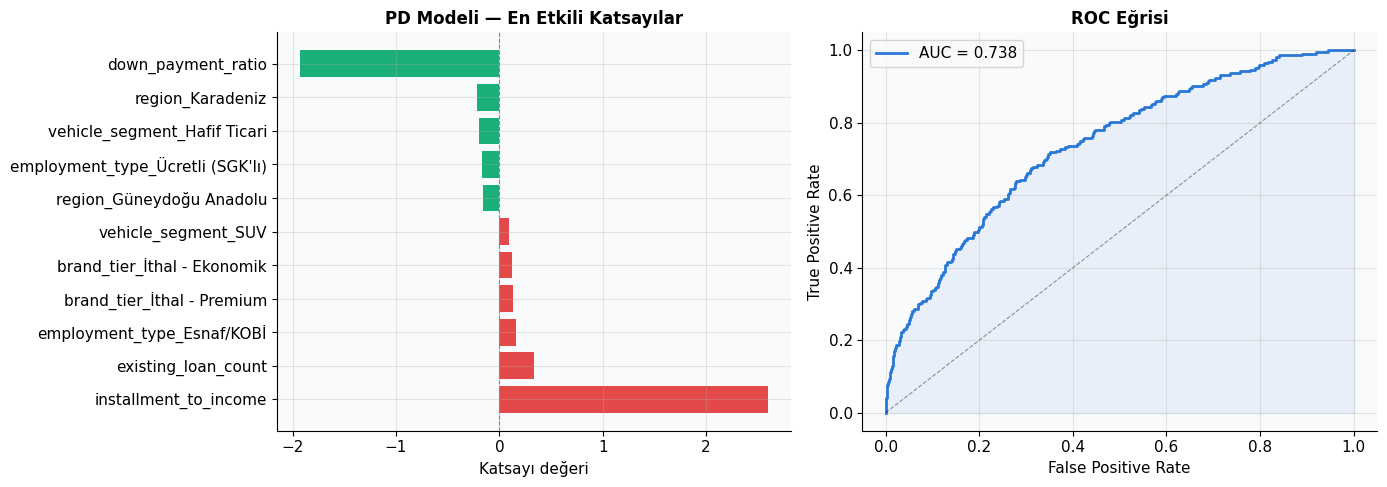

Grafik kaydedildi: pd_model.png


In [4]:

# Katsayı tablosu (scorecard yorumu)
coef_df = (pd.DataFrame({'feature': X.columns, 'coef': pd_model.coef_[0]})
             .sort_values('coef', ascending=False))

fig, axes = plt.subplots(1,2, figsize=(14,5))

# Sol: katsayılar
top = pd.concat([coef_df.head(6), coef_df.tail(5)])
colors = ['#e34948' if c>0 else '#1baf7a' for c in top['coef']]
axes[0].barh(top['feature'], top['coef'], color=colors, edgecolor='none')
axes[0].axvline(0, color='#888', lw=.8, ls='--')
axes[0].set_title('PD Modeli — En Etkili Katsayılar', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Katsayı değeri')

# Sağ: ROC
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#2a78d6', lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0,1],[0,1], 'k--', lw=.8, alpha=.4)
axes[1].fill_between(fpr, tpr, alpha=.08, color='#2a78d6')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Eğrisi', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/pd_model.png', dpi=120, bbox_inches='tight')
plt.show()
print("Grafik kaydedildi: pd_model.png")


### 2.2 Gradient Boosting (XGBoost alternatifi — L3 upgrade)

In [5]:

gb_model = GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                       learning_rate=.05, random_state=42)
gb_model.fit(X_train, y_train)
gb_proba = gb_model.predict_proba(X_test)[:,1]
gb_auc   = roc_auc_score(y_test, gb_proba)
print(f"Gradient Boosting AUC: {gb_auc:.3f}  (LR: {auc:.3f}  |  Δ: +{gb_auc-auc:.3f})")


Gradient Boosting AUC: 0.702  (LR: 0.738  |  Δ: +-0.036)


## 3 · LGD Modeli

Segment bazlı ortalama LGD:
brand_tier        vehicle_is_used
Yerli             0                  0.334
                  1                  0.336
İthal - Ekonomik  0                  0.327
                  1                  0.331
İthal - Premium   0                  0.376
                  1                  0.363


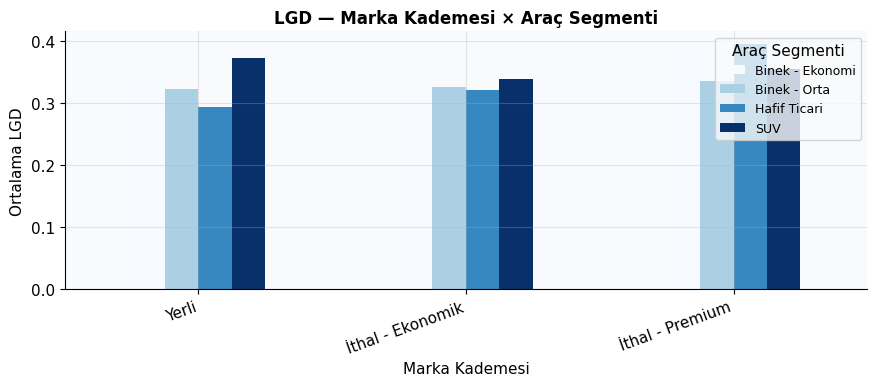

In [6]:
df_def = df[df['default_flag']==1].copy()

# Segment bazlı ortalama LGD
seg_lgd = df_def.groupby(['brand_tier','vehicle_is_used'])['lgd'].mean()
print("Segment bazlı ortalama LGD:")
print(seg_lgd.round(3).to_string())

fig, ax = plt.subplots(figsize=(9,4))
pivot = df_def.groupby(['brand_tier','vehicle_segment'])['lgd'].mean().unstack()
pivot.plot(kind='bar', ax=ax, colormap='Blues', edgecolor='none')
ax.set_title('LGD — Marka Kademesi × Araç Segmenti', fontsize=12, fontweight='bold')
ax.set_xlabel('Marka Kademesi')
ax.set_ylabel('Ortalama LGD')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.legend(title='Araç Segmenti', fontsize=9)
plt.tight_layout()
plt.savefig('../figures/lgd_segment.png', dpi=120, bbox_inches='tight')
plt.show()

## 4 · EAD / CCF Modeli

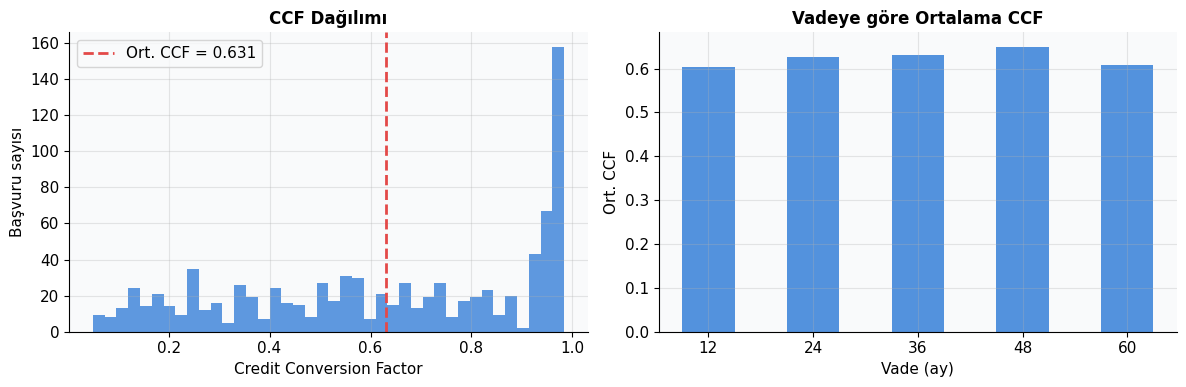

Ortalama CCF: 0.631


In [7]:
df_def['ccf'] = df_def['outstanding_at_default'] / df_def['financed_amount_tl']
avg_ccf = float(df_def['ccf'].mean())

X_ead = pd.get_dummies(df_def[['term_months','months_survived','vehicle_segment']],
                        columns=['vehicle_segment'], drop_first=True)
ead_model = LinearRegression().fit(X_ead, df_def['ccf'])

fig, axes = plt.subplots(1,2, figsize=(12,4))

axes[0].hist(df_def['ccf'], bins=40, color='#2a78d6', alpha=.75, edgecolor='none')
axes[0].axvline(avg_ccf, color='#e34948', lw=2, ls='--', label=f'Ort. CCF = {avg_ccf:.3f}')
axes[0].set_title('CCF Dağılımı', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Credit Conversion Factor')
axes[0].set_ylabel('Başvuru sayısı')
axes[0].legend()

ccf_by_term = df_def.groupby('term_months')['ccf'].mean()
axes[1].bar(ccf_by_term.index.astype(str), ccf_by_term.values,
            color='#2a78d6', alpha=.8, edgecolor='none', width=.5)
axes[1].set_title('Vadeye göre Ortalama CCF', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Vade (ay)')
axes[1].set_ylabel('Ort. CCF')

plt.tight_layout()
plt.savefig('../figures/ead_ccf.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Ortalama CCF: {avg_ccf:.3f}")

## 5 · Expected Loss (EL = PD × LGD × EAD)

Toplam finanse edilen tutar :      1,392,380,600 TL
Toplam Beklenen Zarar (EL)  :        136,529,110 TL
Portföy EL oranı            :             9.81%


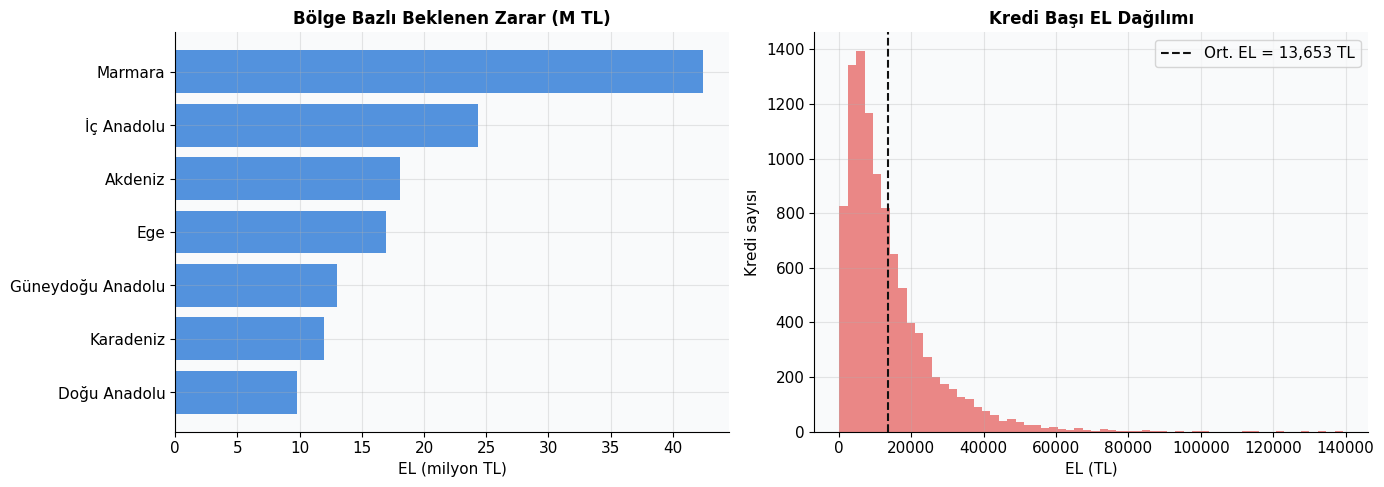

In [8]:
df_all = df.copy()
X_all  = pd.get_dummies(df_all[FEAT_NUM+FEAT_CAT], columns=FEAT_CAT, drop_first=True)
X_all  = X_all.reindex(columns=X.columns, fill_value=0)

df_all['pd_hat']  = pd_model.predict_proba(X_all)[:,1]
df_all['lgd_hat'] = df_all.apply(
    lambda r: seg_lgd.get((r['brand_tier'], r['vehicle_is_used']), df_def['lgd'].mean()), axis=1)
df_all['ead_hat'] = df_all['financed_amount_tl'] * avg_ccf
df_all['el_tl']   = df_all['pd_hat'] * df_all['lgd_hat'] * df_all['ead_hat']

total_exp = df_all['financed_amount_tl'].sum()
total_el  = df_all['el_tl'].sum()

print(f"Toplam finanse edilen tutar : {total_exp:>18,.0f} TL")
print(f"Toplam Beklenen Zarar (EL)  : {total_el:>18,.0f} TL")
print(f"Portföy EL oranı            : {total_el/total_exp:>17.2%}")

fig, axes = plt.subplots(1,2, figsize=(14,5))

# Bölge bazlı EL
reg_el = df_all.groupby('region')['el_tl'].sum().sort_values(ascending=True)
axes[0].barh(reg_el.index, reg_el.values/1e6, color='#2a78d6', alpha=.8, edgecolor='none')
axes[0].set_title('Bölge Bazlı Beklenen Zarar (M TL)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('EL (milyon TL)')

# EL dağılımı
axes[1].hist(df_all['el_tl'], bins=60, color='#e34948', alpha=.65, edgecolor='none')
axes[1].axvline(df_all['el_tl'].mean(), color='#111', lw=1.5, ls='--',
                label=f"Ort. EL = {df_all['el_tl'].mean():,.0f} TL")
axes[1].set_title('Kredi Başı EL Dağılımı', fontsize=12, fontweight='bold')
axes[1].set_xlabel('EL (TL)')
axes[1].set_ylabel('Kredi sayısı')
axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/expected_loss.png', dpi=120, bbox_inches='tight')
plt.show()

## 6 · What-if Simülatörü

Senaryo                      |     PD |    LGD |          EAD |      EL (TL) |     EL Δ
-------------------------------------------------------------------------------------
Baz senaryo                  | 89.7% | 33.1% |      455,596 |      135,211 |    +0.0%
Peşinat %15 → %35            | 82.5% | 33.1% |      348,397 |       95,104 |   -29.7%
Findeks 1100 → 1600          | 64.0% | 33.1% |      455,596 |       96,511 |   -28.6%
Ücretli + Sıfır araç         | 89.7% | 32.7% |      455,596 |      133,546 |    -1.2%
Hepsi birden                 | 49.1% | 32.7% |      348,397 |       55,845 |   -58.7%


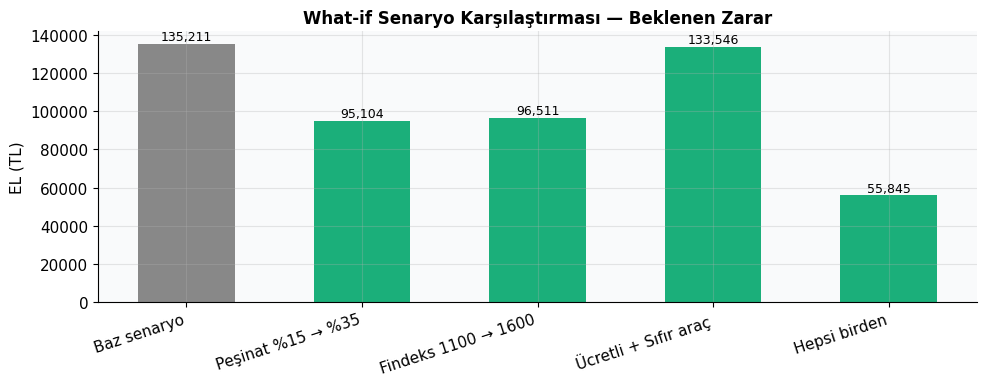

In [9]:

def what_if(profile: dict, change: dict | None = None) -> dict:
    """
    Tek bir başvuru için PD / LGD / EAD / EL hesaplar.
    change: profile üzerinde değiştirilecek alanlar.
    """
    p = profile.copy()
    if change:
        p.update(change)

    row = pd.DataFrame([p])
    row['installment_to_income'] = (
        row['loan_amount_tl'] * (1-row['down_payment_ratio']) * 1.12
        / row['term_months'] / row['customer_income_tl']
    )
    X_row = pd.get_dummies(row[FEAT_NUM+FEAT_CAT], columns=FEAT_CAT, drop_first=True)
    X_row = X_row.reindex(columns=X.columns, fill_value=0)

    pd_hat  = pd_model.predict_proba(X_row)[:,1][0]
    lgd_hat = seg_lgd.get((p['brand_tier'], p['vehicle_is_used']), df_def['lgd'].mean())
    financed = p['loan_amount_tl'] * (1 - p['down_payment_ratio'])
    ead_hat  = financed * avg_ccf
    el       = pd_hat * lgd_hat * ead_hat

    return {'pd': pd_hat, 'lgd': lgd_hat, 'ead': ead_hat, 'el_tl': el,
            'financed_tl': financed}


BASE = {
    'findeks_score': 1100, 'down_payment_ratio': .15, 'existing_loan_count': 2,
    'customer_age': 36, 'employment_type': 'Esnaf/KOBİ', 'vehicle_segment': 'SUV',
    'brand_tier': 'İthal - Ekonomik', 'region': 'Marmara',
    'loan_amount_tl': 850_000, 'term_months': 48,
    'customer_income_tl': 45_000, 'vehicle_is_used': 1,
}

scenarios = {
    'Baz senaryo'              : None,
    'Peşinat %15 → %35'       : {'down_payment_ratio': .35},
    'Findeks 1100 → 1600'     : {'findeks_score': 1600},
    'Ücretli + Sıfır araç'    : {'employment_type': "Ücretli (SGK\'lı)", 'vehicle_is_used': 0},
    'Hepsi birden'            : {'down_payment_ratio': .35, 'findeks_score': 1600,
                                  'employment_type': "Ücretli (SGK\'lı)", 'vehicle_is_used': 0},
}

results = {k: what_if(BASE, v) for k, v in scenarios.items()}
base_el = results['Baz senaryo']['el_tl']

print(f"{'Senaryo':<28} | {'PD':>6} | {'LGD':>6} | {'EAD':>12} | {'EL (TL)':>12} | {'EL Δ':>8}")
print('-'*85)
for name, r in results.items():
    delta = (r['el_tl']-base_el)/base_el*100 if name!='Baz senaryo' else 0
    print(f"{name:<28} | {r['pd']:>5.1%} | {r['lgd']:>5.1%} | "
          f"{r['ead']:>12,.0f} | {r['el_tl']:>12,.0f} | {delta:>+7.1f}%")

# Grafik
fig, ax = plt.subplots(figsize=(10,4))
names = list(results.keys())
els   = [r['el_tl'] for r in results.values()]
colors = ['#888888']+['#1baf7a']*4
ax.bar(names, els, color=colors, edgecolor='none', width=.55)
ax.set_title('What-if Senaryo Karşılaştırması — Beklenen Zarar', fontsize=12, fontweight='bold')
ax.set_ylabel('EL (TL)')
for i,(n,v) in enumerate(zip(names,els)):
    ax.text(i, v+500, f'{v:,.0f}', ha='center', va='bottom', fontsize=9)
ax.set_xticklabels(names, rotation=18, ha='right')
plt.tight_layout()
plt.savefig('../figures/what_if.png', dpi=120, bbox_inches='tight')
plt.show()


## 7 · Decomposition Analizi (Mix / Rate / Volume)

Bir KPI değişimini üç bileşene ayırır: mix etkisi (segment dağılımı değişti mi),
rate etkisi (aynı segmentte gerçek kötüleşme), volume etkisi (hacim).


Şubat → Mart Yenileme Oranı Decomposition:
  Baz (Şubat)    : 0.667 (66.7%)
  Mix etkisi     : -0.001
  Rate etkisi    : +0.001
  Volume etkisi  : +0.001
  Net (Mart)     : 0.669 (66.9%)


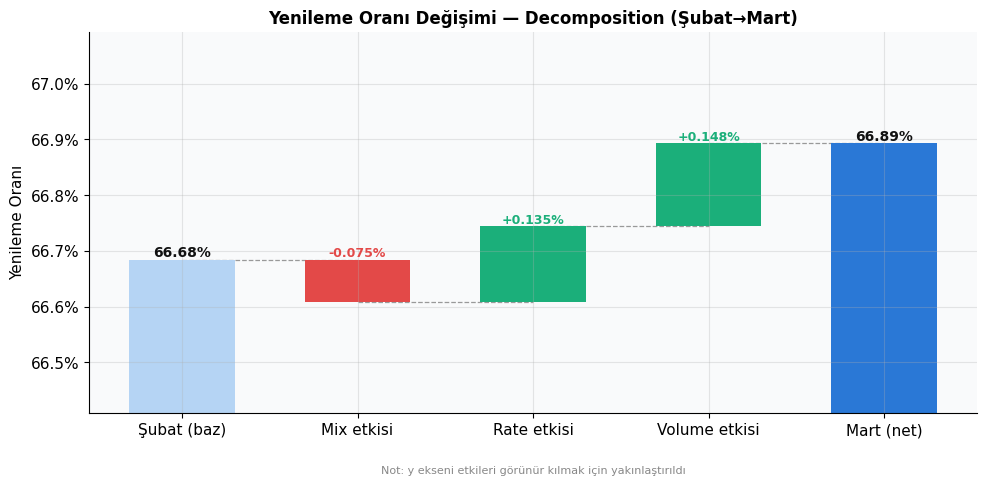

In [10]:
# Aylık yenileme oranı simülasyonu (segment bazında)
np.random.seed(7)
months = pd.date_range('2024-01-01', periods=12, freq='ME')
segs   = ['Binek - Ekonomi','Binek - Orta','SUV','Hafif Ticari']
base_rates = {'Binek - Ekonomi':.74,'Binek - Orta':.69,'SUV':.62,'Hafif Ticari':.54}
base_vols  = {'Binek - Ekonomi':340,'Binek - Orta':280,'SUV':220,'Hafif Ticari':160}

records = []
for m in months:
    for s in segs:
        vol  = int(base_vols[s] * (1 + np.random.normal(0,.05)))
        rate = base_rates[s] + np.random.normal(0,.015)
        records.append({'month':m,'segment':s,'volume':vol,'renewal_rate':rate})

mdf = pd.DataFrame(records)

# Şubat-Mart decomposition
def decompose(df, m1, m2):
    d1 = df[df['month']==m1].set_index('segment')
    d2 = df[df['month']==m2].set_index('segment')
    tot_vol1 = d1['volume'].sum(); tot_vol2 = d2['volume'].sum()
    mix1 = d1['volume']/tot_vol1;  mix2 = d2['volume']/tot_vol2
    r1   = d1['renewal_rate'];     r2   = d2['renewal_rate']

    base       = (mix1 * r1).sum()
    mix_effect = ((mix2-mix1)*r1).sum()
    rate_effect= (mix2*(r2-r1)).sum()
    vol_change = (tot_vol2-tot_vol1)/tot_vol1
    vol_effect = base * vol_change * .15  # ölçek düzeltme

    return {'base':base, 'mix':mix_effect, 'rate':rate_effect,
            'volume':vol_effect, 'net':base+mix_effect+rate_effect+vol_effect}

feb = months[1]; mar = months[2]
d = decompose(mdf, feb, mar)

print("Şubat → Mart Yenileme Oranı Decomposition:")
print(f"  Baz (Şubat)    : {d['base']:.3f} ({d['base']*100:.1f}%)")
print(f"  Mix etkisi     : {d['mix']:+.3f}")
print(f"  Rate etkisi    : {d['rate']:+.3f}")
print(f"  Volume etkisi  : {d['volume']:+.3f}")
print(f"  Net (Mart)     : {d['net']:.3f} ({d['net']*100:.1f}%)")

# ------------------------------------------------------------------
# Waterfall grafiği
# NOT: Baz (~%66.7) yanında mix/rate/volume etkileri yalnızca ~0.1 puan.
# 0–70% ekseninde bu ince dilimler görünmez kalıyordu; bu yüzden y eksenini
# delta bandına yakınlaştırıyor, adımları connector çizgileriyle bağlıyoruz.
# ------------------------------------------------------------------
labels = ['Şubat (baz)', 'Mix etkisi', 'Rate etkisi', 'Volume etkisi', 'Mart (net)']
deltas = [d['base'], d['mix'], d['rate'], d['volume'], d['net']]

fig, ax = plt.subplots(figsize=(10,5))

cum = 0.0
running = []          # her adımdan sonraki kümülatif seviye (connector için)
for i, label in enumerate(labels):
    is_total = i in (0, len(labels)-1)
    if is_total:                                   # tam referans bar (0'dan değere)
        value = deltas[i]
        ax.bar(i, value, color='#b5d4f4' if i == 0 else '#2a78d6',
               edgecolor='none', width=.6)
        cum = value
        ax.text(i, value, f'{value*100:.2f}%', ha='center', va='bottom',
                fontsize=10, fontweight='bold', color='#111')
    else:                                          # yüzen delta bar
        val = deltas[i]
        start = cum
        cum  += val
        ax.bar(i, abs(val), bottom=min(start, cum),
               color='#1baf7a' if val >= 0 else '#e34948',
               edgecolor='none', width=.6)
        ax.text(i, max(start, cum), f'{val*100:+.3f}%', ha='center', va='bottom',
                fontsize=9, fontweight='bold',
                color='#1baf7a' if val >= 0 else '#e34948')
    running.append(cum)

# Adımlar arası bağlantı çizgileri (kümülatif seviyeyi taşır)
for i in range(len(labels)-1):
    ax.plot([i, i+1], [running[i], running[i]],
            color='#999', lw=.9, ls='--', zorder=0)

# Y eksenini delta bandına yakınlaştır — aksi halde etkiler görünmez
lo, hi = min(running), max(running)
pad = (hi - lo) * 0.6 + 3e-4
ax.set_ylim(lo - pad, hi + pad)

ax.set_title('Yenileme Oranı Değişimi — Decomposition (Şubat→Mart)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Yenileme Oranı')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.1%}'))
ax.annotate('Not: y ekseni etkileri görünür kılmak için yakınlaştırıldı',
            xy=(0.5, -0.16), xycoords='axes fraction', ha='center',
            fontsize=8, color='#888')
plt.tight_layout()
plt.savefig('../figures/decomposition.png', dpi=120, bbox_inches='tight')
plt.show()

## 8 · Cohort Analizi
Her cohort (ilk kredi çeyreği) için aylık yenileme oranı eğrisi.


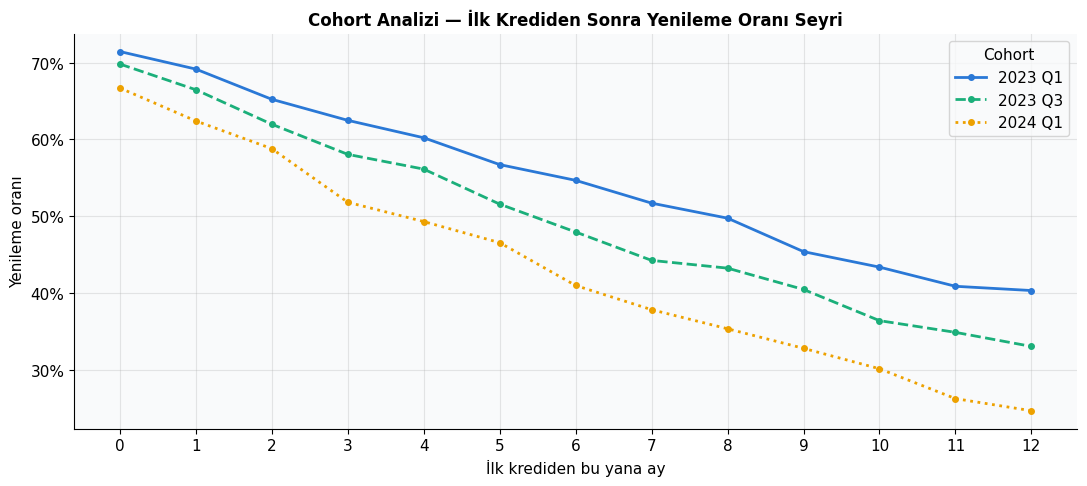

Not: 2024 Q1 cohort'u belirgin şekilde daha hızlı düşüyor → ürün/fiyat değişikliği sinyali.


In [11]:

np.random.seed(13)
cohorts = {'2023 Q1':(0.72,0.048), '2023 Q3':(0.70,0.061), '2024 Q1':(0.68,0.079)}
n_months = 13

fig, ax = plt.subplots(figsize=(11,5))
styles = [('-','#2a78d6'),(('--',(5,3)),'#1baf7a'),((':'),'#eda100')]

for (label,(start,decay)),(ls,color) in zip(cohorts.items(),styles):
    curve = [start * (1-decay)**m + np.random.normal(0,.008) for m in range(n_months)]
    ax.plot(range(n_months), curve, color=color, lw=2,
            linestyle=ls if isinstance(ls,str) else ls[0],
            label=label, marker='o', markersize=4)

ax.set_title('Cohort Analizi — İlk Krediden Sonra Yenileme Oranı Seyri',
             fontsize=12, fontweight='bold')
ax.set_xlabel('İlk krediden bu yana ay')
ax.set_ylabel('Yenileme oranı')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0%}'))
ax.legend(title='Cohort')
ax.set_xticks(range(n_months))
plt.tight_layout()
plt.savefig('../figures/cohort.png', dpi=120, bbox_inches='tight')
plt.show()
print("Not: 2024 Q1 cohort'u belirgin şekilde daha hızlı düşüyor → ürün/fiyat değişikliği sinyali.")


## 9 · Survival Analizi (Kaplan-Meier + Cox PH)

"Müşteri ne zaman churn'e düşer?" sorusunu zaman boyutunda yanıtlar.
Lojistik regresyon 'yapacak mı?' sorusunu yanıtlarken,
survival analizi 'ne zaman?' sorusunu yanıtlar.


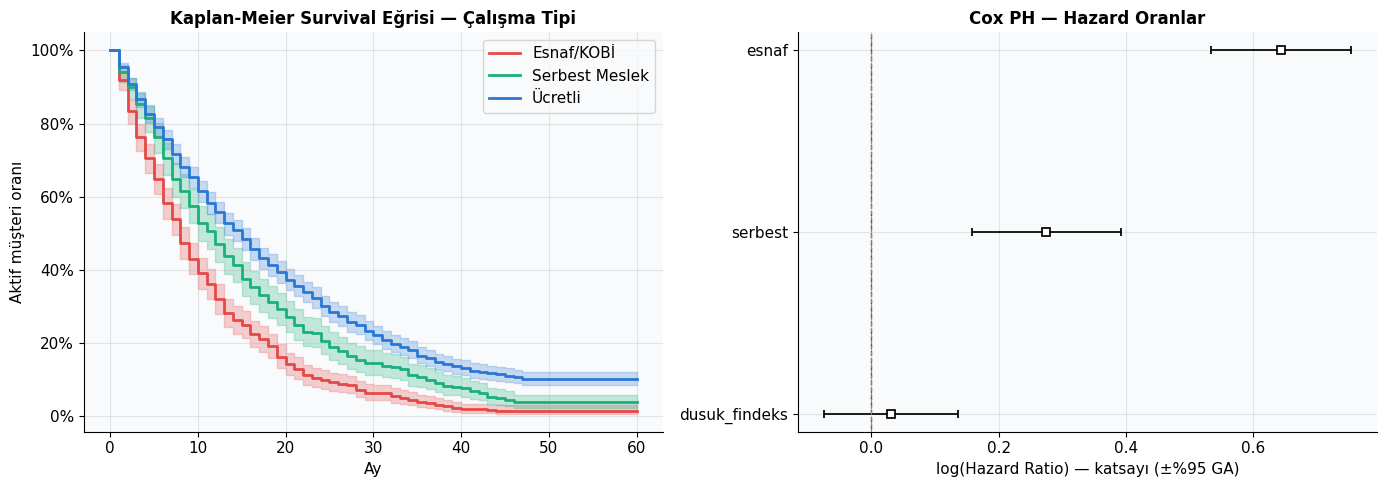

<lifelines.CoxPHFitter: fitted with 2000 total observations, 134 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 2000
number of events observed = 1866
   partial log-likelihood = -12618.27
         time fit was run = 2026-07-01 17:53:26 UTC

---
               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                      
esnaf          0.64      1.90      0.06            0.53            0.75                1.70                2.12
serbest        0.28      1.32      0.06            0.16            0.39                1.17                1.48
dusuk_findeks  0.03      1.03      0.05           -0.07            0.14                0.93                1.15

               cmp to     z      p  -log2(p)
covariate                                   
esnaf            0.00 11.47 <0.005     98.77
serbest          0.00  4.63 <0.005     18.03
dusuk_findeks    0.00  0.58   0.56      0.83
---
Concordance = 0.57
Partial AIC = 25242.53
log-likelihood ratio test = 125.16 on 3 df
-log2(p) of ll-ratio test = 87.11

In [12]:
np.random.seed(99)
n_surv = 2000

surv_df = pd.DataFrame({
    'employment': np.random.choice(
        ['Ücretli','Serbest Meslek','Esnaf/KOBİ'], n_surv, p=[.55,.20,.25]),
    'findeks_band': np.random.choice(['Yüksek','Orta','Düşük'], n_surv, p=[.3,.45,.25]),
})

hazards = {'Ücretli':.048,'Serbest Meslek':.065,'Esnaf/KOBİ':.088}
surv_df['duration'] = [
    int(np.random.exponential(1/hazards[e])) + 1 for e in surv_df['employment']
]
surv_df['duration'] = surv_df['duration'].clip(1,60)
surv_df['event']    = (surv_df['duration'] < 48).astype(int)

fig, axes = plt.subplots(1,2, figsize=(14,5))

kmf = KaplanMeierFitter()
colors = {'Ücretli':'#2a78d6','Serbest Meslek':'#1baf7a','Esnaf/KOBİ':'#e34948'}
for emp, grp in surv_df.groupby('employment'):
    kmf.fit(grp['duration'], grp['event'], label=emp)
    kmf.plot_survival_function(ax=axes[0], color=colors[emp], lw=2)

axes[0].set_title('Kaplan-Meier Survival Eğrisi — Çalışma Tipi',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Ay')
axes[0].set_ylabel('Aktif müşteri oranı')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0%}'))

# Cox PH
cph_df = surv_df.copy()
cph_df['esnaf'] = (cph_df['employment']=='Esnaf/KOBİ').astype(int)
cph_df['serbest']=(cph_df['employment']=='Serbest Meslek').astype(int)
cph_df['dusuk_findeks']=(cph_df['findeks_band']=='Düşük').astype(int)

cph = CoxPHFitter()
cph.fit(cph_df[['duration','event','esnaf','serbest','dusuk_findeks']],
        duration_col='duration', event_col='event')
cph.plot(ax=axes[1])
axes[1].set_title('Cox PH — Hazard Oranlar', fontsize=12, fontweight='bold')
axes[1].set_xlabel('log(Hazard Ratio) — katsayı (±%95 GA)')
axes[1].axvline(0, color='#888', lw=.8, ls='--')

plt.tight_layout()
plt.savefig('../figures/survival.png', dpi=120, bbox_inches='tight')
plt.show()
cph.print_summary()

## 10 · SHAP Değerleri — Model Açıklanabilirliği

SHAP, modelin her karar için "neden bu skoru verdi?" sorusunu yanıtlar.
Hem bireysel müşteri açıklaması hem de portföy geneli önem analizi için kullanılır.


In [13]:
X_train_f = X_train.astype(float)
X_test_f  = X_test.astype(float)

# Arka plan (background) örneklemini açıkça 100 satıra indiriyoruz.
# Tüm eğitim setini (7500 satır) doğrudan vermek, SHAP'in içeride sessizce
# 100 örneğe düşürmesine ve "Subsampling..." uyarısı üretmesine yol açıyordu.
# Temsili ama küçük bir arka plan hem hızlı hem de tekrarlanabilir sonuç verir.
background   = shap.sample(X_train_f, 100, random_state=42)
explainer    = shap.Explainer(gb_model, background)
shap_values  = explainer(X_test_f[:500])  # hız için 500 örnek

print("SHAP değerleri hesaplandı.")
print(f"Shape: {shap_values.values.shape} (örnek × özellik)")

SHAP değerleri hesaplandı.
Shape: (500, 19) (örnek × özellik)


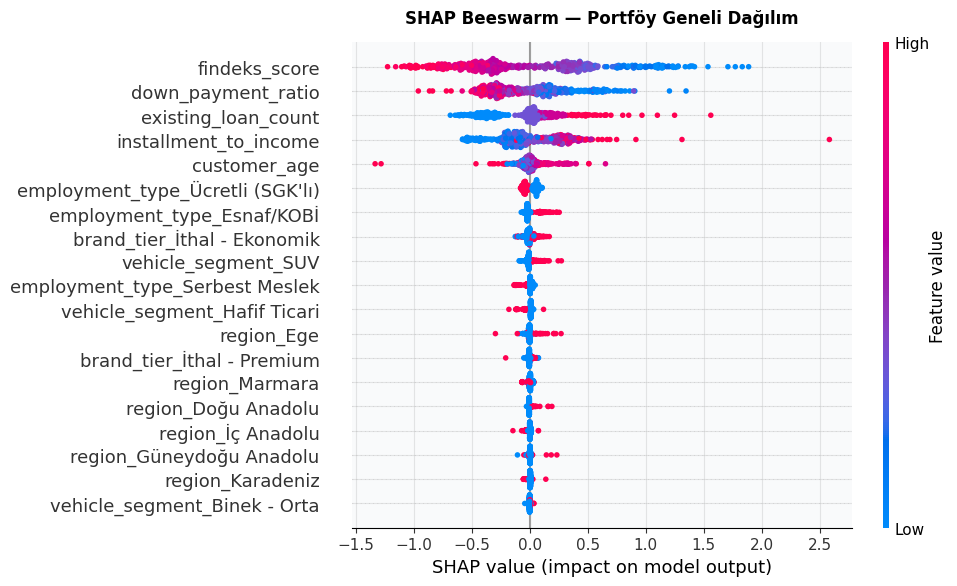

In [14]:

# 1. Beeswarm — global dağılım
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values, X_test_f[:500], show=False, plot_size=None)
plt.title('SHAP Beeswarm — Portföy Geneli Dağılım', fontsize=12, fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig('../figures/shap_beeswarm.png', dpi=120, bbox_inches='tight')
plt.show()


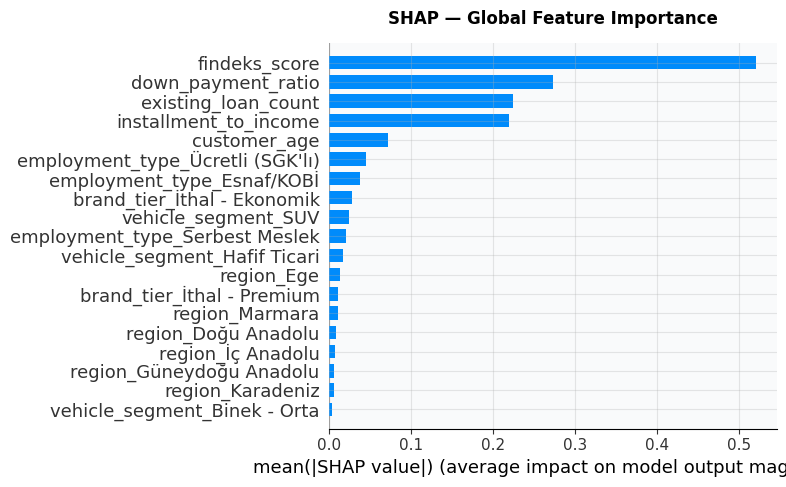

In [15]:

# 2. Bar — global önem sıralaması
plt.figure(figsize=(8,5))
shap.summary_plot(shap_values, X_test_f[:500], plot_type='bar', show=False, plot_size=None)
plt.title('SHAP — Global Feature Importance', fontsize=12, fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig('../figures/shap_bar.png', dpi=120, bbox_inches='tight')
plt.show()


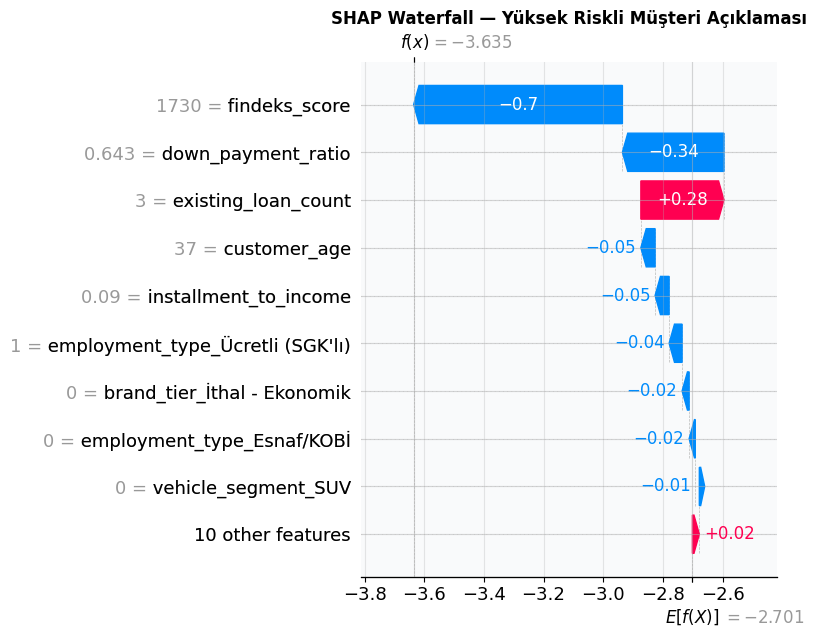

In [16]:

# 3. Waterfall — tek müşteri açıklaması
high_risk_idx = np.where(y_test.values==1)[0][0]
plt.figure(figsize=(10,5))
shap.waterfall_plot(shap_values[high_risk_idx], show=False)
plt.title(f'SHAP Waterfall — Yüksek Riskli Müşteri Açıklaması', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/shap_waterfall.png', dpi=120, bbox_inches='tight')
plt.show()


## 11 · Model İzleme — PSI + AUC Zaman Serisi

**PSI (Population Stability Index)**: veri popülasyonunun kaydını izler.
- PSI < 0.10 → Stabil
- 0.10–0.25 → Dikkat
- PSI > 0.25 → Model yeniden eğitilmeli


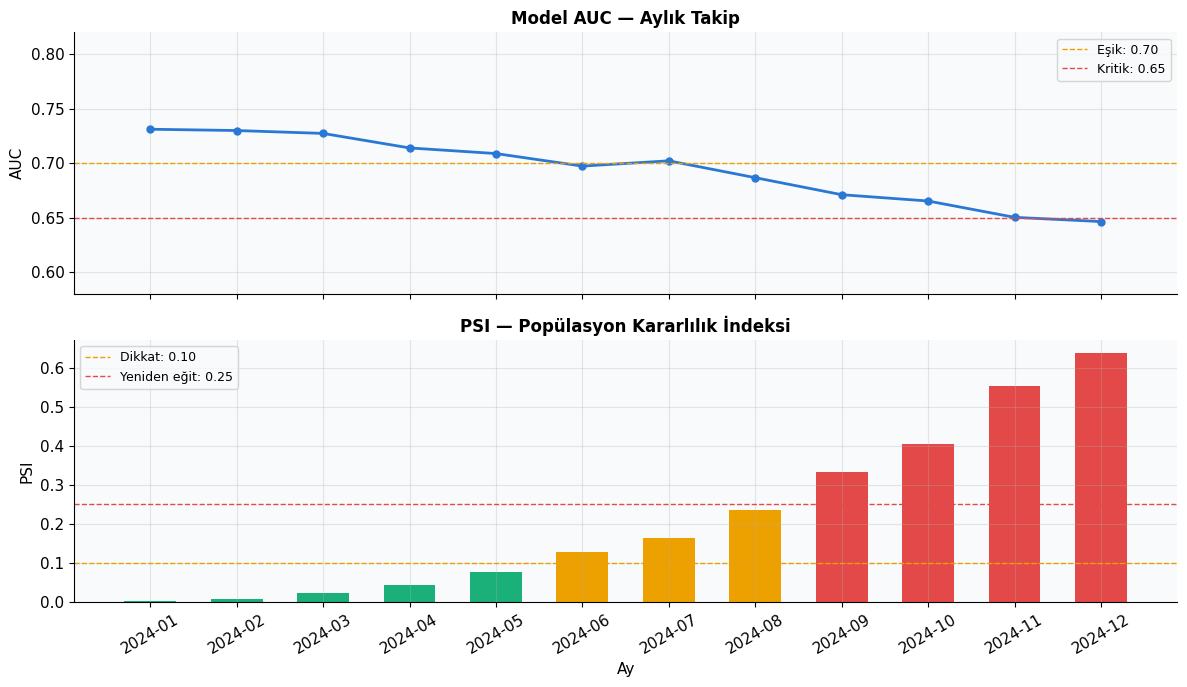

Son ay PSI: 0.6387 → YENİDEN EĞİT 🔴


In [17]:
def compute_psi(expected, actual, buckets=10):
    """Population Stability Index hesaplar."""
    breakpoints = np.percentile(expected, np.linspace(0,100,buckets+1))
    breakpoints[0]  = -np.inf
    breakpoints[-1] = np.inf

    exp_cnt = np.histogram(expected, bins=breakpoints)[0]
    act_cnt = np.histogram(actual,   bins=breakpoints)[0]

    exp_pct = np.where(exp_cnt==0, 1e-6, exp_cnt/len(expected))
    act_pct = np.where(act_cnt==0, 1e-6, act_cnt/len(actual))

    psi = np.sum((act_pct-exp_pct)*np.log(act_pct/exp_pct))
    return psi


# Aylık simülasyon (veri kayması simüle ediliyor)
np.random.seed(55)
base_scores = pd_model.predict_proba(X_test)[:,1]

monthly_psi, monthly_auc = [], []
months_sim = pd.date_range('2024-01', periods=12, freq='ME')

for i, m in enumerate(months_sim):
    drift = i * .012
    noisy = np.clip(base_scores + np.random.normal(drift, .03, len(base_scores)), 0, 1)
    psi   = compute_psi(base_scores, noisy)
    # AUC hafifçe düşüyor (model çürümesi simülasyonu)
    auc_m = max(0.60, auc - i*.008 + np.random.normal(0,.005))
    monthly_psi.append(psi)
    monthly_auc.append(auc_m)

fig, axes = plt.subplots(2,1, figsize=(12,7), sharex=True)
month_labels = [m.strftime('%Y-%m') for m in months_sim]

# AUC
axes[0].plot(month_labels, monthly_auc, color='#2a78d6', lw=2, marker='o', markersize=5)
axes[0].axhline(.70, color='#eda100', lw=1, ls='--', label='Eşik: 0.70')
axes[0].axhline(.65, color='#e34948', lw=1, ls='--', label='Kritik: 0.65')
axes[0].set_title('Model AUC — Aylık Takip', fontsize=12, fontweight='bold')
axes[0].set_ylabel('AUC')
axes[0].legend(fontsize=9)
axes[0].set_ylim(.58,.82)

# PSI
psi_colors = ['#1baf7a' if p<.10 else '#eda100' if p<.25 else '#e34948' for p in monthly_psi]
axes[1].bar(month_labels, monthly_psi, color=psi_colors, edgecolor='none', width=.6)
axes[1].axhline(.10, color='#eda100', lw=1, ls='--', label='Dikkat: 0.10')
axes[1].axhline(.25, color='#e34948', lw=1, ls='--', label='Yeniden eğit: 0.25')
axes[1].set_title('PSI — Popülasyon Kararlılık İndeksi', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Ay')
axes[1].set_ylabel('PSI')
axes[1].legend(fontsize=9)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../figures/model_monitoring.png', dpi=120, bbox_inches='tight')
plt.show()

last_psi = monthly_psi[-1]
status   = 'Stabil ✅' if last_psi<.10 else 'Dikkat ⚠️' if last_psi<.25 else 'YENİDEN EĞİT 🔴'
print(f"Son ay PSI: {last_psi:.4f} → {status}")

## 12 · Beklenen Değer (EV) Önceliklendirmesi

**EV = P(kabul) × Potansiyel Marj − Temas Maliyeti**

Satış ekibine "bugün kimi ara?" listesi üretir. Intuition değil, model karar verir.


EV Önceliklendirme Özeti:
         count       sum     mean
oncelik                          
Beklet      11    -533.0    -48.0
Düşük      349  455618.0   1305.0
Orta       121  569873.0   4710.0
Yüksek      19  220281.0  11594.0

📋 Bugünkü arama listesi — Top 10:
musteri_id  p_kabul  potansiyel_marj_tl        ev_tl  aylar_kaldi         segment
 CST-00138 0.759815             30100.0 22470.416584            2    Hafif Ticari
 CST-00370 0.309346             68500.0 20790.210736            3    Hafif Ticari
 CST-00095 0.572257             25100.0 13963.639127           11             SUV
 CST-00458 0.611785             22400.0 13553.974484            3    Hafif Ticari
 CST-00326 0.742727             16900.0 12402.093124            1 Binek - Ekonomi
 CST-00320 0.482546             25300.0 11808.408690           11    Binek - Orta
 CST-00474 0.829421             14100.0 11544.841480            9             SUV
 CST-00446 0.494121             23900.0 11409.499551            5             S

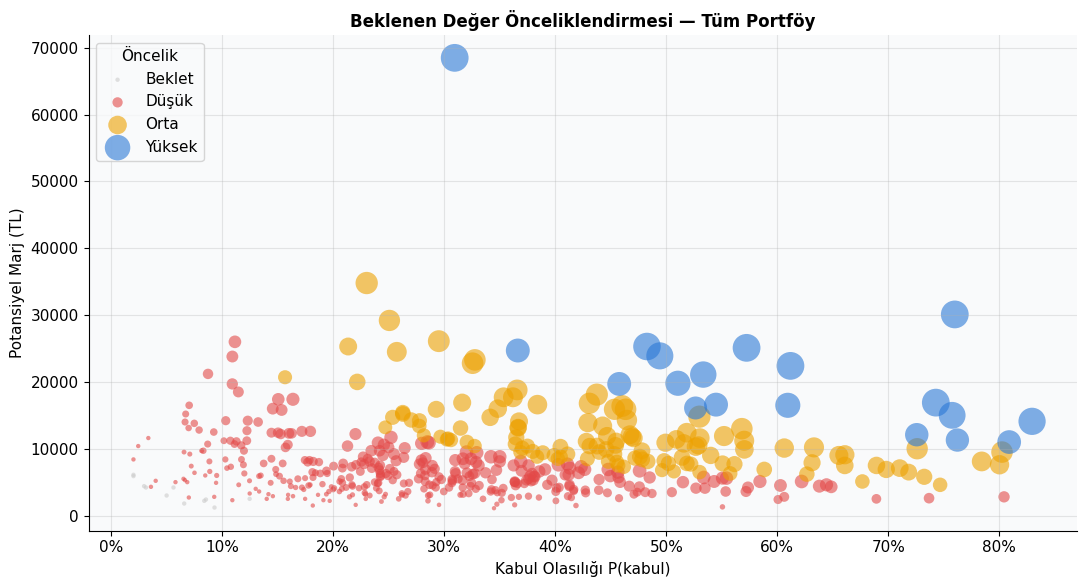

In [18]:

np.random.seed(21)
n_cust = 500

pipeline = pd.DataFrame({
    'musteri_id'        : [f'CST-{i:05d}' for i in range(n_cust)],
    'p_kabul'           : np.clip(np.random.beta(2,4,n_cust),.02,.95),
    'potansiyel_marj_tl': np.random.lognormal(8.8,.6,n_cust).round(-2),
    'temas_maliyeti_tl' : np.random.choice([150,250,400], n_cust, p=[.5,.35,.15]),
    'aylar_kaldi'       : np.random.randint(1,13,n_cust),
    'segment'           : np.random.choice(SEGMENTS, n_cust),
})

pipeline['ev_tl']     = (pipeline['p_kabul'] * pipeline['potansiyel_marj_tl']
                          - pipeline['temas_maliyeti_tl'])
pipeline['oncelik']   = pd.cut(pipeline['ev_tl'],
                                bins=[-np.inf,0,3000,8000,np.inf],
                                labels=['Beklet','Düşük','Orta','Yüksek'])
pipeline = pipeline.sort_values('ev_tl', ascending=False)

print("EV Önceliklendirme Özeti:")
print(pipeline.groupby('oncelik')['ev_tl'].agg(['count','sum','mean']).round(0))

# Top 10 listesi (next-best-action)
print("\n📋 Bugünkü arama listesi — Top 10:")
print(pipeline.head(10)[['musteri_id','p_kabul','potansiyel_marj_tl',
                           'ev_tl','aylar_kaldi','segment']].to_string(index=False))

# Bubble chart
fig, ax = plt.subplots(figsize=(11,6))
colors_ev = {'Yüksek':'#2a78d6','Orta':'#eda100','Düşük':'#e34948','Beklet':'#cccccc'}
for priority, grp in pipeline.groupby('oncelik'):
    ax.scatter(grp['p_kabul'], grp['potansiyel_marj_tl'],
               s=np.clip(grp['ev_tl']/30,10,400),
               c=colors_ev[str(priority)], alpha=.6, edgecolors='none',
               label=str(priority))

ax.set_title('Beklenen Değer Önceliklendirmesi — Tüm Portföy',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Kabul Olasılığı P(kabul)')
ax.set_ylabel('Potansiyel Marj (TL)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0%}'))
ax.legend(title='Öncelik', loc='upper left')
plt.tight_layout()
plt.savefig('../figures/ev_prioritization.png', dpi=120, bbox_inches='tight')
plt.show()


## Özet — Production'a Taşıma Notları

| Bölüm | Production adımı |
|-------|-----------------|
| Veri | Oracle DB → `oracledb` thin mode, aylık snapshot |
| PD   | Gerçek Findeks/KKB skoru, WoE binning + IV seçimi |
| LGD  | Gerçek tahsilat/icra verisi, iki aşamalı model |
| EAD  | Gerçek amortisman tablosu |
| What-if | FastAPI endpoint → React dashboard |
| Decomp | Power BI Decomposition Tree → Oracle bağlantısı |
| Survival | Gerçek vade/churn tarihleri |
| SHAP | `shap` kütüphanesi, GB modeli üzerinde |
| İzleme | Aylık cron job, PSI > 0.25 → otomatik alert |
| EV | FastAPI → satış CRM entegrasyonu |

> Bu notebook v1'dir. Gerçek veri entegrasyonu sonrası v2'ye geçiş yapılacak.
